In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

tips = sns.load_dataset("tips")

In [2]:
tips.head()                 
tips.describe()             
tips.info()                 
tips.isnull().sum()         


for col in tips.columns:
    if tips[col].dtype.kind in "biufc":          
        tips[col] = tips[col].fillna(tips[col].mean())
    else:                                        
        tips[col] = tips[col].fillna(tips[col].mode()[0])

# Counts for categorical variables
tips["sex"].value_counts()
tips["day"].value_counts()
tips["time"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


time
Dinner    176
Lunch      68
Name: count, dtype: int64

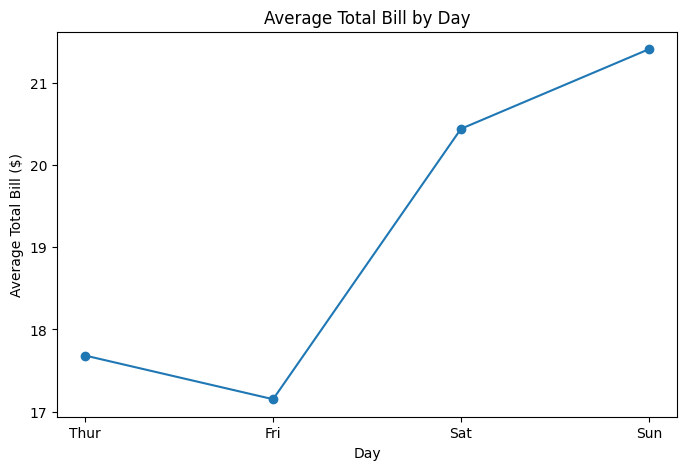

In [3]:
avg_by_day = tips.groupby("day", observed=True)["total_bill"].mean()
plt.figure(figsize=(8,5))
plt.plot(avg_by_day.index, avg_by_day.values, marker="o")
plt.title("Average Total Bill by Day")
plt.xlabel("Day"); plt.ylabel("Average Total Bill ($)")
plt.show()

Weekend days (especially Sunday ~$21.4 and Saturday ~$20.4) have higher average bills than weekdays (Thur ~$17.7, Fri ~$17.2). Spending rises toward the weekend, consistent with larger/leisurely dinners.

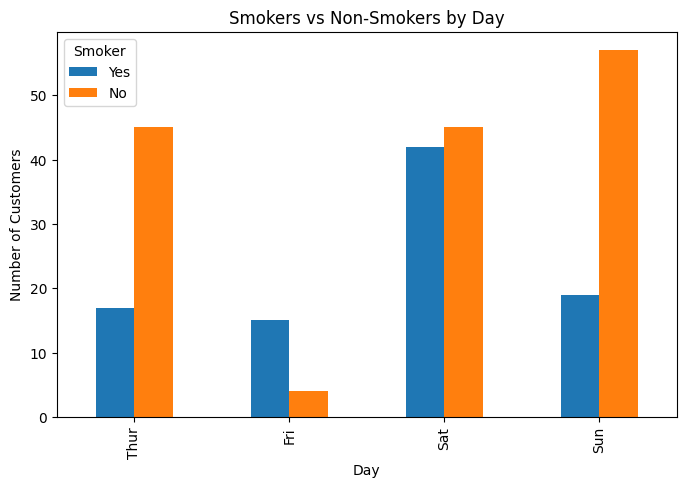

In [4]:
counts = tips.groupby(["day","smoker"], observed=True).size().unstack()
counts.plot(kind="bar", figsize=(8,5))
plt.title("Smokers vs Non-Smokers by Day")
plt.xlabel("Day"); plt.ylabel("Number of Customers")
plt.legend(title="Smoker")
plt.show()

Non-smokers outnumber smokers on every day (151 vs 93 overall). The gap is widest on Thursday and Sunday; Saturday has the most smokers in absolute terms but non-smokers still lead.

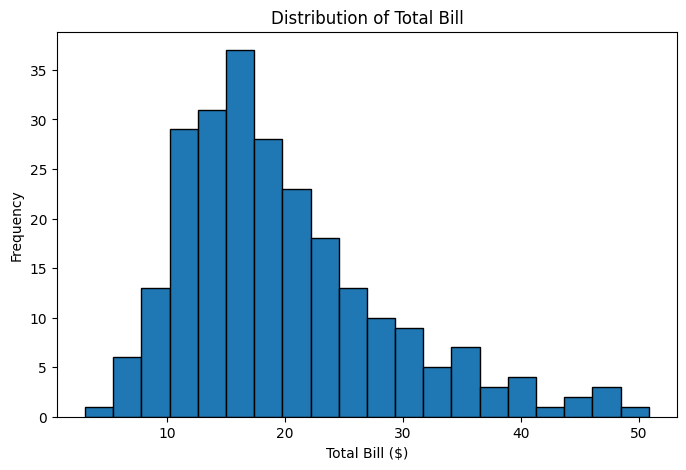

In [5]:
plt.figure(figsize=(8,5))
plt.hist(tips["total_bill"], bins=20, edgecolor="black")
plt.title("Distribution of Total Bill")
plt.xlabel("Total Bill ($)"); plt.ylabel("Frequency")
plt.show()

Right-skewed (skewed toward lower values): most bills cluster in the $10–20 range with a long tail toward higher bills. One dominant peak (mode) around $15–18; the long right tail pulls the mean above the median.

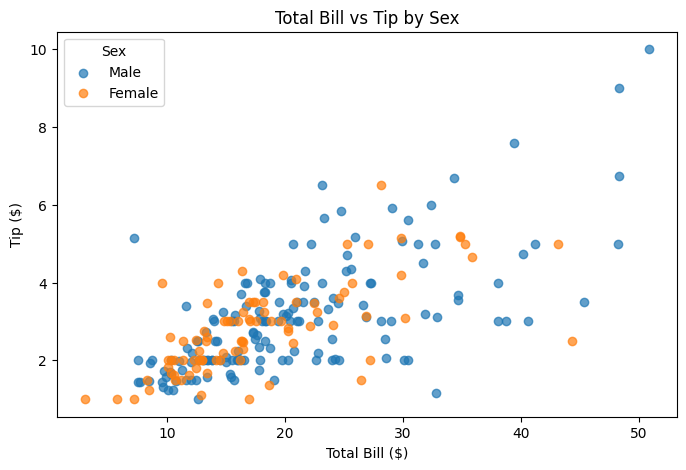

In [6]:
plt.figure(figsize=(8,5))
for sex, grp in tips.groupby("sex", observed=True):
    plt.scatter(grp["total_bill"], grp["tip"], label=sex, alpha=0.7)
plt.title("Total Bill vs Tip by Sex")
plt.xlabel("Total Bill ($)"); plt.ylabel("Tip ($)")
plt.legend(title="Sex")
plt.show()

Positive correlation (~0.68): tips rise with the bill. There are outliers high bills with disproportionately low tips (e.g., a ~$50 bill tipping only a few dollars). Males tend to have slightly higher total bills on average, but tip rate is similar between sexes.

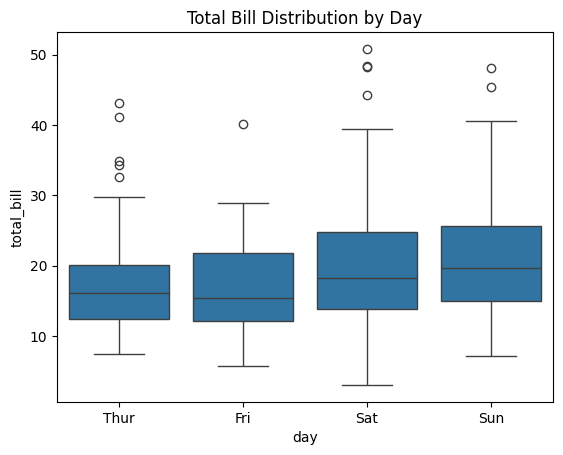

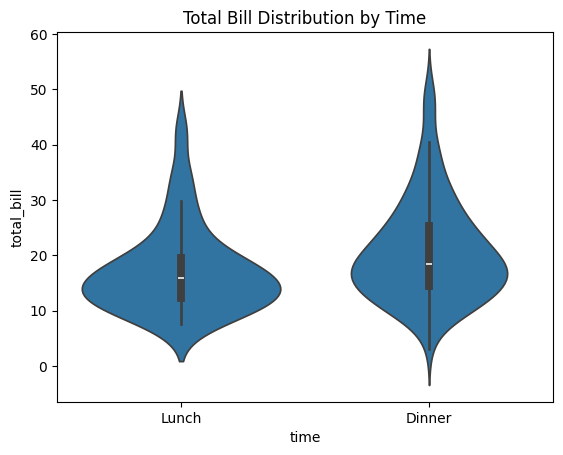

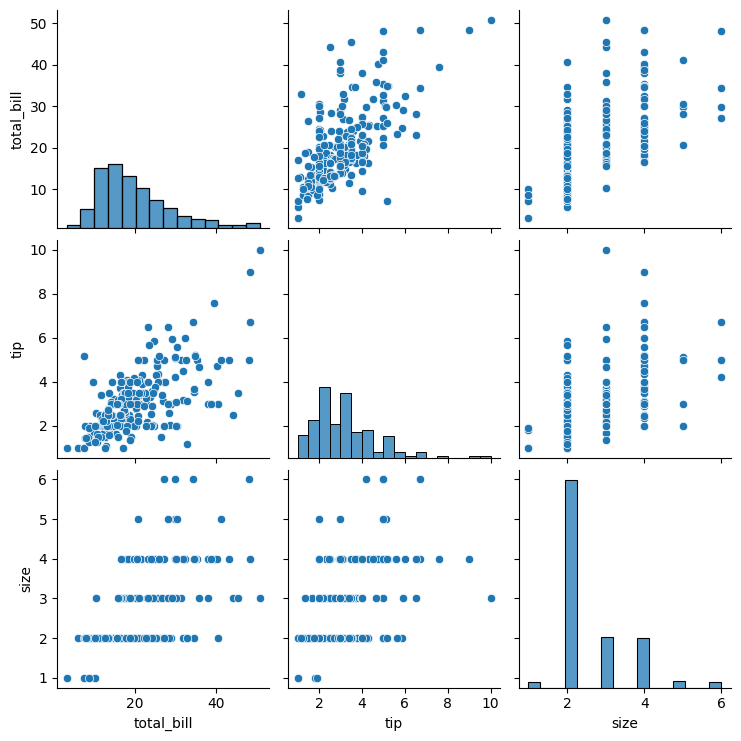

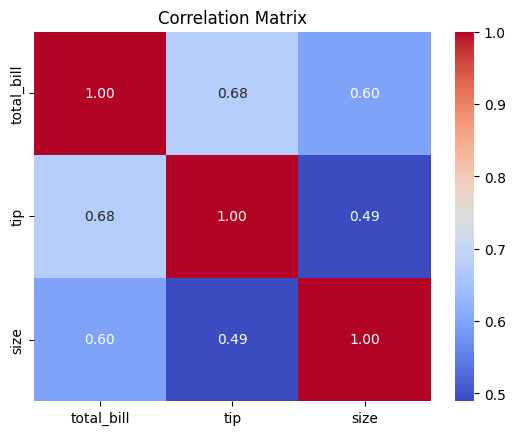

In [ ]:
sns.boxplot(data=tips, x="day", y="total_bill")
plt.title("Total Bill Distribution by Day"); plt.show()

sns.violinplot(data=tips, x="time", y="total_bill")
plt.title("Total Bill Distribution by Time"); plt.show()

sns.pairplot(tips[["total_bill","tip","size"]])
plt.show()

corr = tips[["total_bill","tip","size"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix"); plt.show()

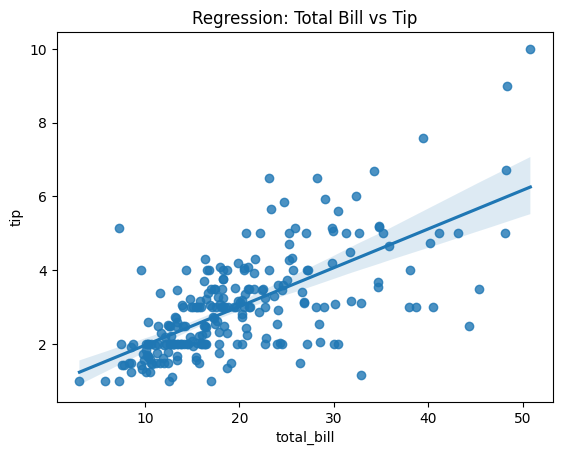

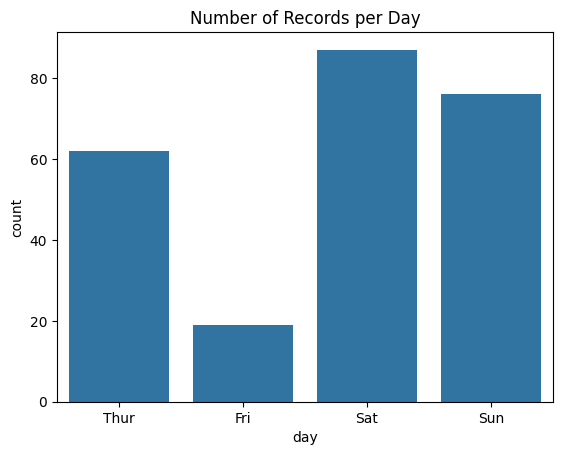

In [8]:
sns.regplot(data=tips, x="total_bill", y="tip")
plt.title("Regression: Total Bill vs Tip"); plt.show()

sns.countplot(data=tips, x="day")
plt.title("Number of Records per Day"); plt.show()

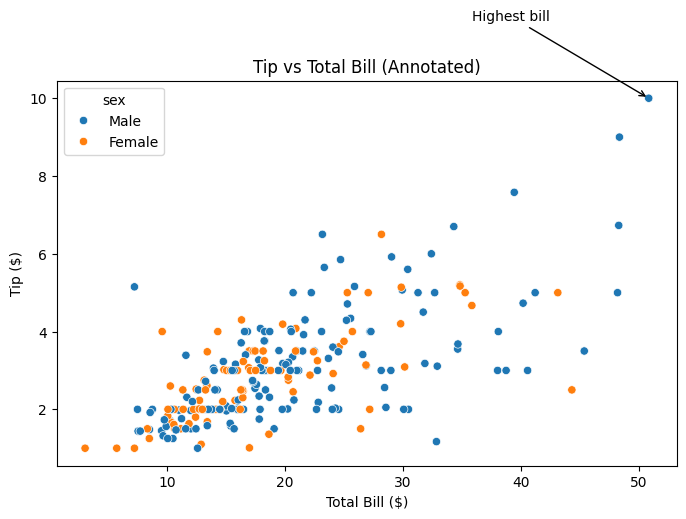

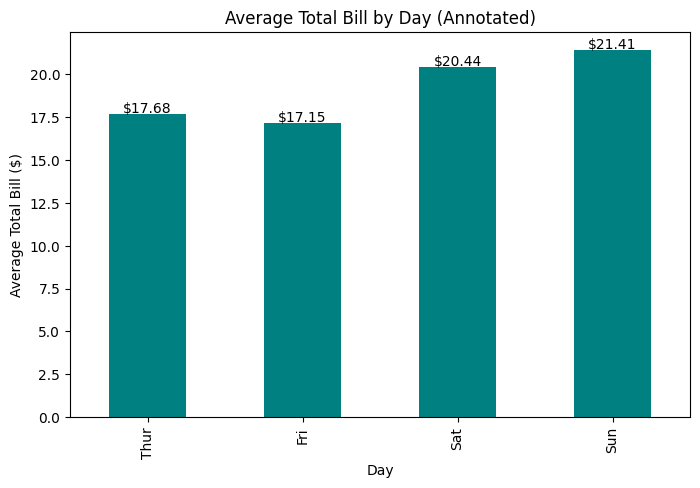

In [9]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=tips, x="total_bill", y="tip", hue="sex")
max_row = tips.loc[tips["total_bill"].idxmax()]
plt.annotate("Highest bill",
             xy=(max_row["total_bill"], max_row["tip"]),
             xytext=(max_row["total_bill"]-15, max_row["tip"]+2),
             arrowprops=dict(arrowstyle="->"))
plt.title("Tip vs Total Bill (Annotated)")
plt.xlabel("Total Bill ($)"); plt.ylabel("Tip ($)")
plt.show()

ax = avg_by_day.plot(kind="bar", figsize=(8,5), color="teal")
for i, v in enumerate(avg_by_day.values):
    ax.text(i, v+0.1, f"${v:.2f}", ha="center")
plt.title("Average Total Bill by Day (Annotated)")
plt.xlabel("Day"); plt.ylabel("Average Total Bill ($)")
plt.show()